<div align="center">

<div align="center">
<img src="../images/logo_adela.jpg" alt="logo" width="800"/>
</div>

## ADeLA 2025

## Región de atacama, Chile

</div>

# https://github.com/stevenalfonso/ADeLA-2025

# Outline

* The membership problem
* Unsupervised techniques
    * DBSCAN
    * HDBSCAN

<div align="center">

# The membership problem

<div align="center">
<img src="../images/membership.png" alt="membership" width="700"/>
</div>

</div>

* Proper motions (the classic probability approach)
* Machine learning (unsupervised techniques on astrometric data)
    * $\alpha$, $\delta$, $\mu_{\alpha}$, $\mu_{\delta}$, $\varpi$, $v_{\text{rad}}$

### Distance Metrics for DBSCAN & HDBSCAN  

- **Euclidean Distance (`'euclidean'`)**  
  The straight-line distance between two points in an n-dimensional space:  
  $$
  d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
  $$  

- **Manhattan Distance (`'manhattan'`)**  
  Also called **Taxicab** or **L1 distance**, it sums the absolute differences along each dimension:  
  $$
  d(x, y) = \sum_{i=1}^{n} |x_i - y_i|
  $$  

- **Minkowski Distance (`'minkowski'`)**  
  A generalization of both Euclidean and Manhattan distances:  
  $$
  d(x, y) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{\frac{1}{p}}
  $$  
  - If **p = 1**, it becomes the **Manhattan Distance**.  
  - If **p = 2**, it becomes the **Euclidean Distance**.  

- **Mahalanobis Distance (`'mahalanobis'`)**  
  Accounts for correlations between variables and scales differently in different directions:  
  $$
  d_M(x, y) = \sqrt{(x - y)^T S^{-1} (x - y)}
  $$  
  where **S** is the covariance matrix of the data.  


<div align="center">

# DBSCAN

DBSCAN identifies overdensities by computing distances between points in the data set. It mainly depends on two hyperparameters: minPts and 𝜖 (Ester +1996)

<div align="center">
<img src="../images/dbscan.png" alt="membership" width="600"/>
</div>

Schematic representation with minPts = 3 (Castro-Ginard+2018)

</div>


Points are classified as: 
- <span style="color:green">Core points</span>
- <span style="color:blue">Border points</span>
- <span style="color:red">Outliers</span>


### DBSCAN Hyperparameters  

- **`eps` (ϵ - Epsilon):**  
  Defines the maximum distance between two points to be considered neighbors.  

- **`min_samples`:**  
  The minimum number of points (including the core point) required to form a dense region.  

- **`metric`:**  
  The distance metric used to measure the similarity between points (default is Euclidean distance).  

In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
#from sklearn.preprocessing import StandardScaler
import numpy as np

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.cluster import HDBSCAN
import astropy.units as u
# from zero_point import zpt
from tqdm import tqdm
from sklearn.cluster import DBSCAN

In [2]:
df = pd.read_csv("Coma_Cluster_GAIA_DR3.csv") 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 99 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   solution_id                      5010 non-null   int64  
 1   designation                      5010 non-null   str    
 2   source_id                        5010 non-null   int64  
 3   random_index                     5010 non-null   int64  
 4   ref_epoch                        5010 non-null   float64
 5   ra                               5010 non-null   float64
 6   ra_error                         5010 non-null   float64
 7   dec                              5010 non-null   float64
 8   dec_error                        5010 non-null   float64
 9   parallax                         5010 non-null   float64
 10  parallax_error                   5010 non-null   float64
 11  parallax_over_error              5010 non-null   float64
 12  pm                             

In [3]:
print("Rango paralaje",df["parallax"].min(),df["parallax"].max())

Rango paralaje 5.000240729191405 83.50380208181748


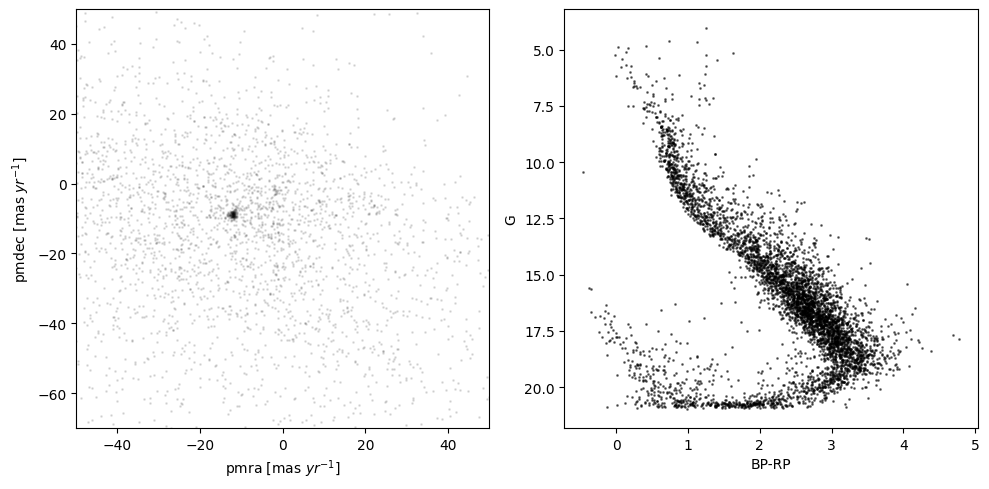

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].scatter(df['pmra'], df['pmdec'], s=1, alpha=0.1, c='k')
ax[0].set_xlabel("pmra [mas $yr^{-1}$]")
ax[0].set_ylabel("pmdec [mas $yr^{-1}$]")
ax[0].set_xlim(-50, 50)
ax[0].set_ylim(-70, 50)

ax[1].scatter(df['phot_bp_mean_mag'] - df['phot_rp_mean_mag'], df['phot_g_mean_mag'], s=1, alpha=0.5, c='k')
ax[1].set_xlabel("BP-RP")
ax[1].set_ylabel("G")
ax[1].invert_yaxis()
fig.tight_layout()

In [5]:
#clustering_on = ['ra','dec','pmra','pmdec','parallax']
clustering_on = ["pmra", "pmdec", "parallax"]
data = df[clustering_on]
data = RobustScaler().fit_transform(data)

In [6]:
# from sklearn.neighbors import NearestNeighbors
# from kneed import KneeLocator

# k = 5  # if min_samples = 10
# nbrs = NearestNeighbors(n_neighbors=k).fit(data)
# distances, indices = nbrs.kneighbors(data)

# k_distances = distances[:, -1]  # Última columna contiene la distancia al k-ésimo vecino
# k_distances = np.sort(k_distances)

# knee = KneeLocator(range(len(k_distances)), k_distances, curve="concave", direction="increasing")
# eps_knee = k_distances[knee.knee]

# plt.plot(k_distances)
# plt.vlines(knee.knee, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='red')
# plt.axhline(y=eps_knee, color='r', linestyle='--', label=f"eps = {np.round(eps_knee, 4)}")
# plt.xlabel("index")
# plt.ylabel(f"Distance to {k}-nearest neighbor")
# plt.title("elbow method")
# plt.legend()
# plt.show()

# DBSCAN

## https://www.kaggle.com/code/pnarerdoan/k-means-dbscan-clustering

In [7]:
eps_grid = np.linspace(0.1, 0.5, 10)
eps_grid

array([0.1       , 0.14444444, 0.18888889, 0.23333333, 0.27777778,
       0.32222222, 0.36666667, 0.41111111, 0.45555556, 0.5       ])

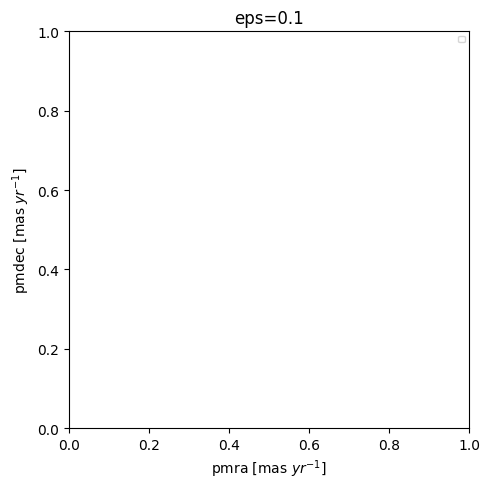

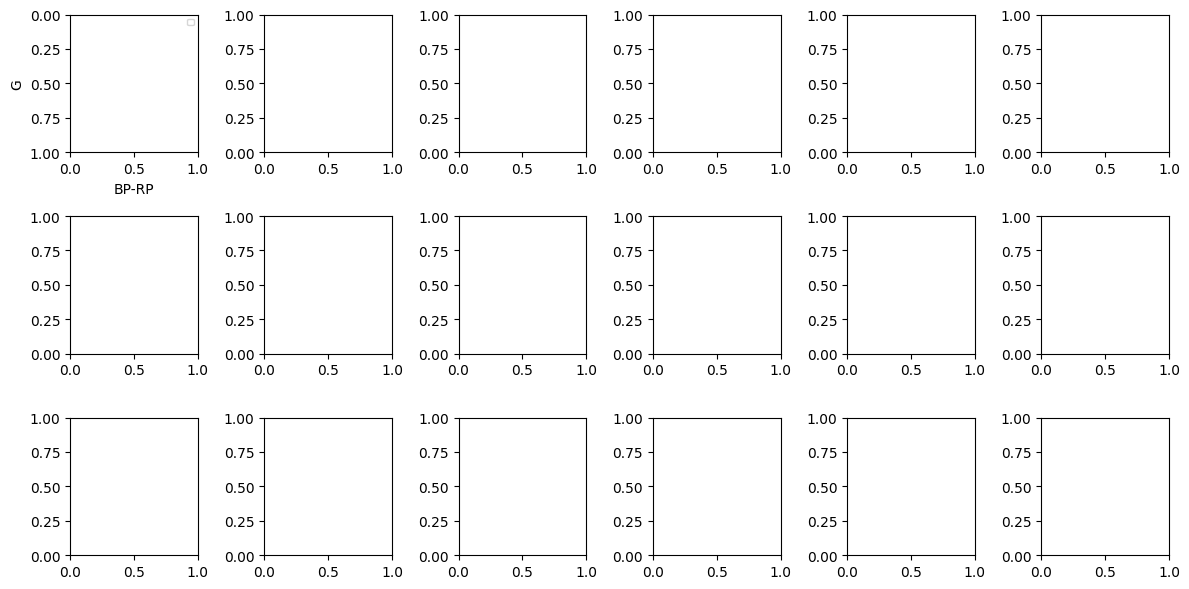

Número de elementos: 130


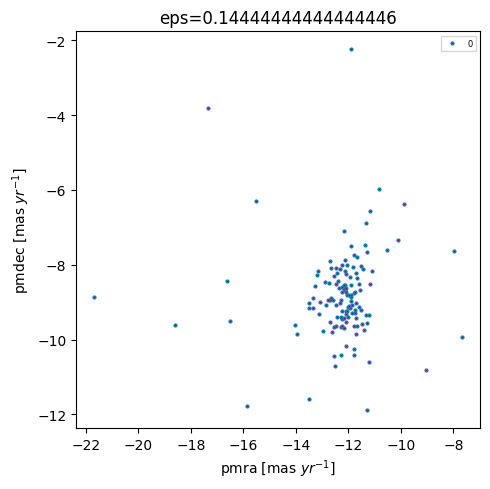

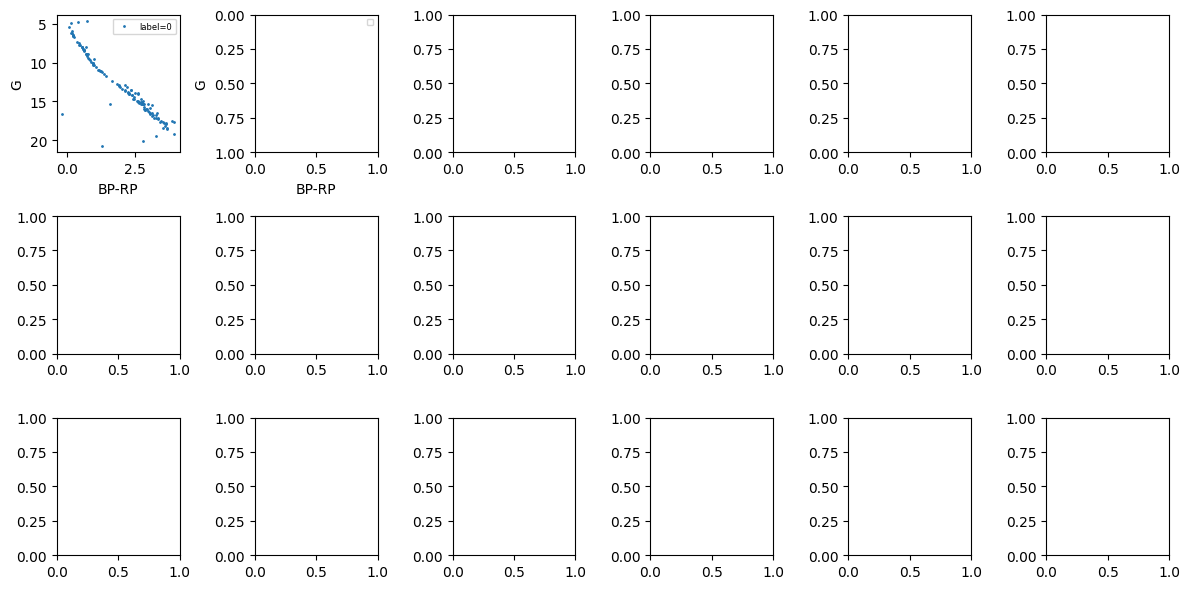

Número de elementos: 141
Número de elementos: 429


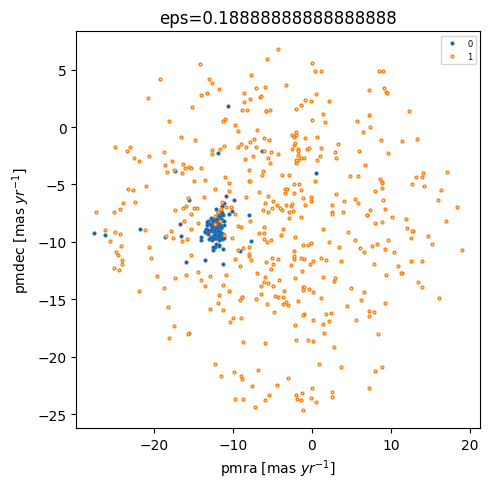

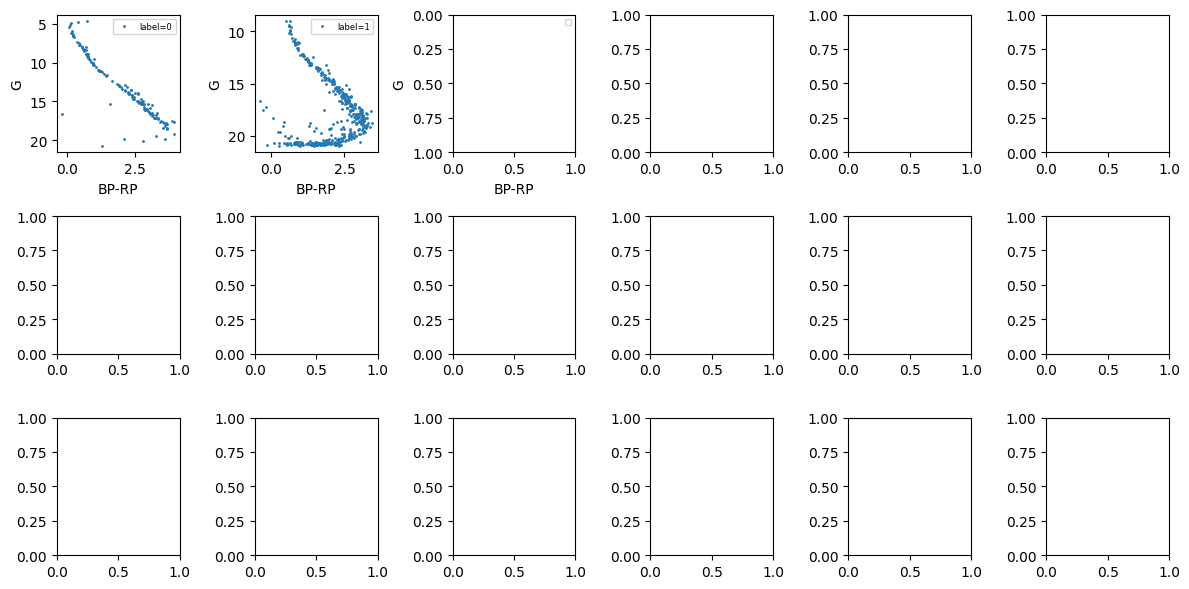

Número de elementos: 1193
Número de elementos: 154


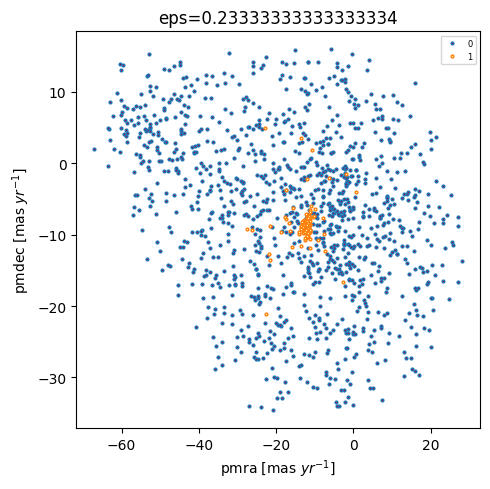

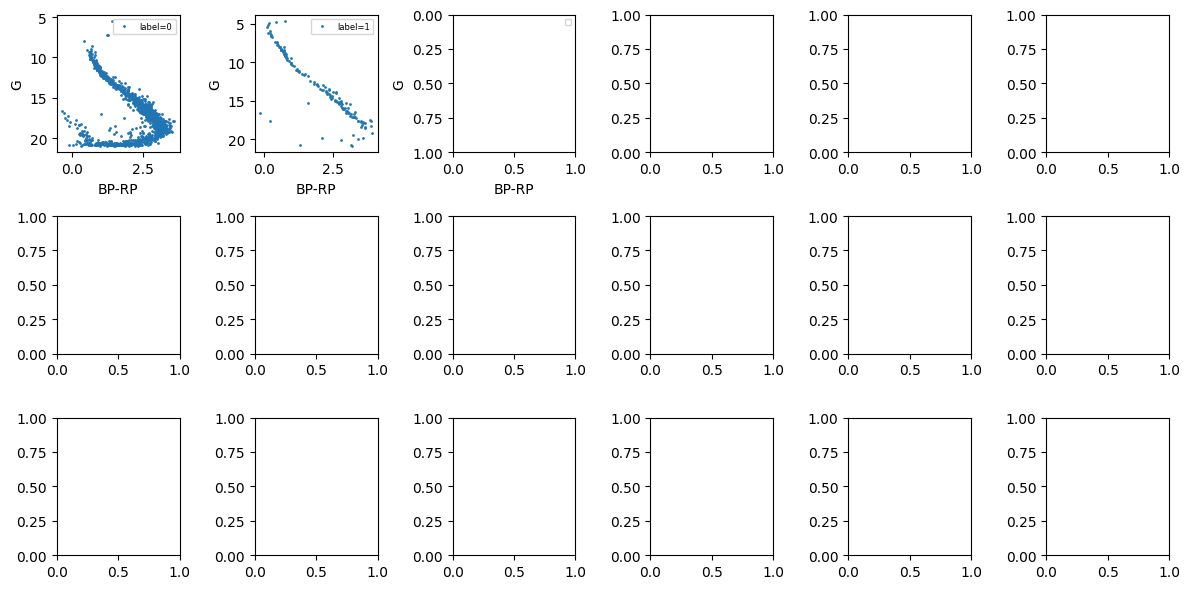

Número de elementos: 1736
Número de elementos: 161


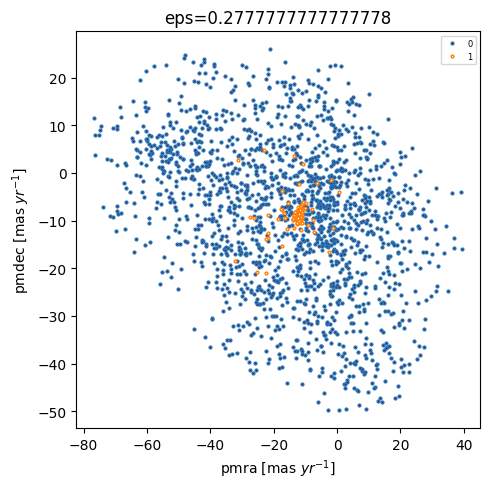

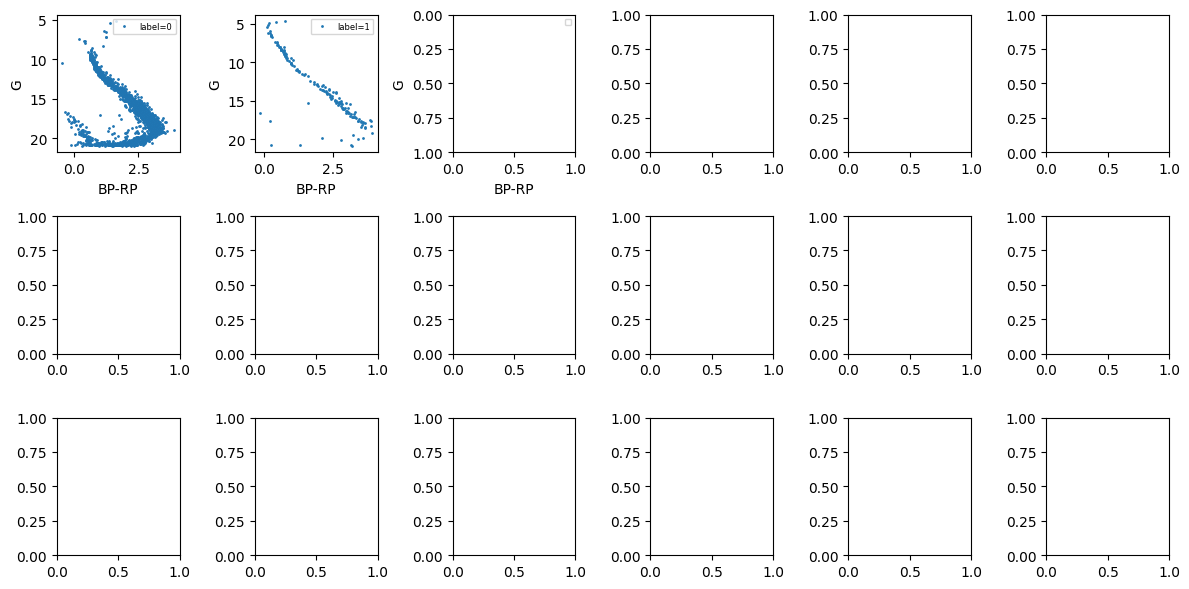

Número de elementos: 2307
Número de elementos: 171


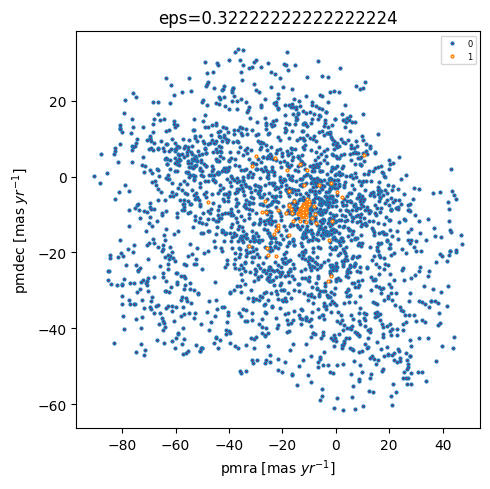

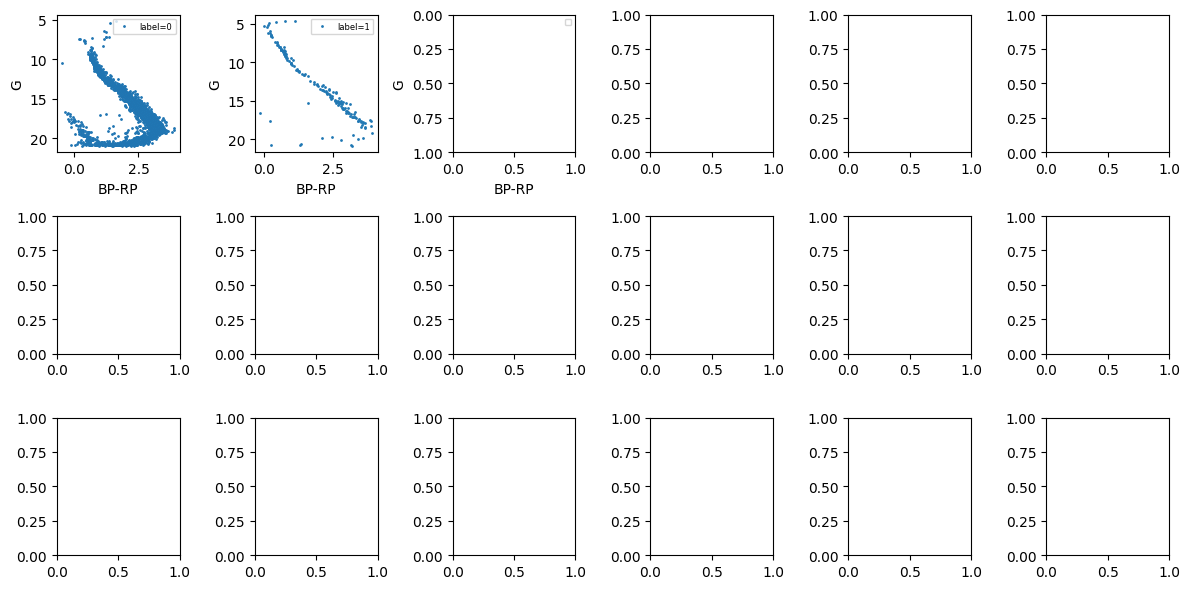

Número de elementos: 2743
Número de elementos: 190


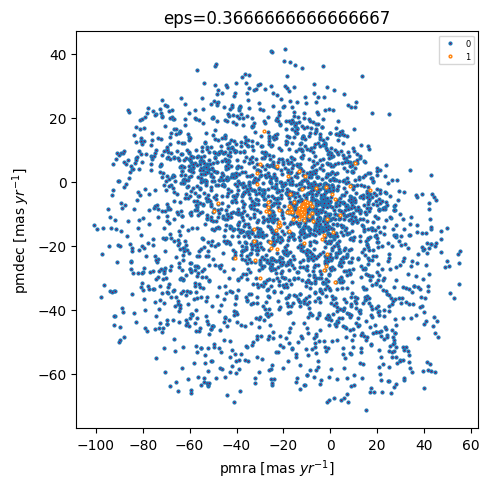

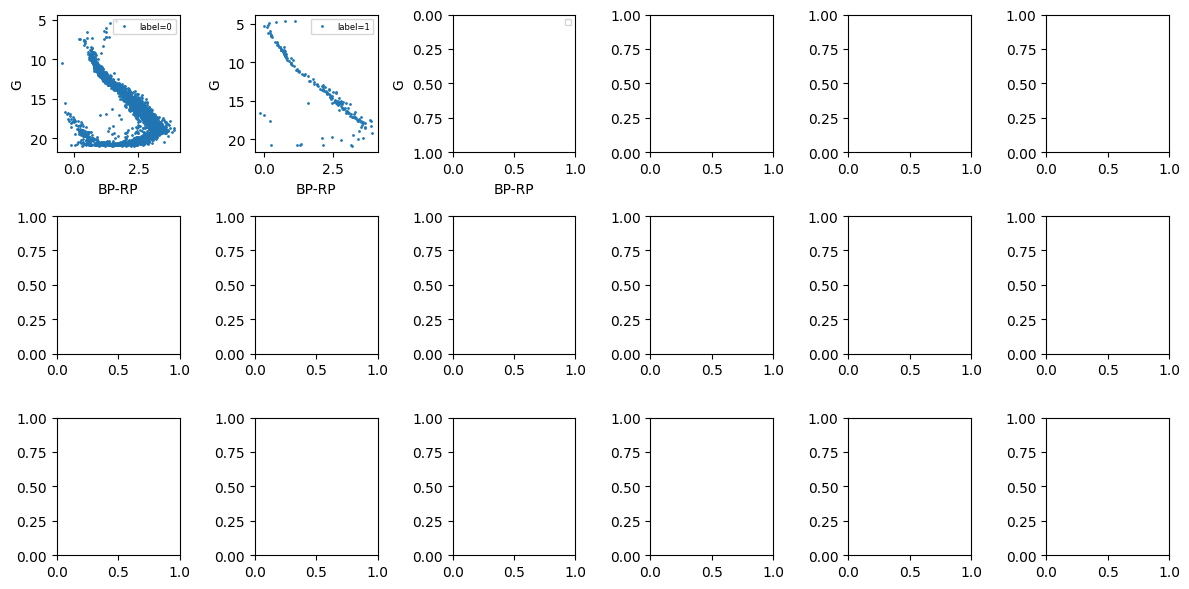

Número de elementos: 3071
Número de elementos: 213


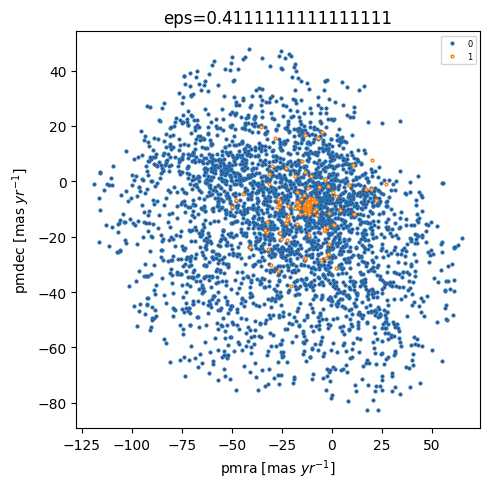

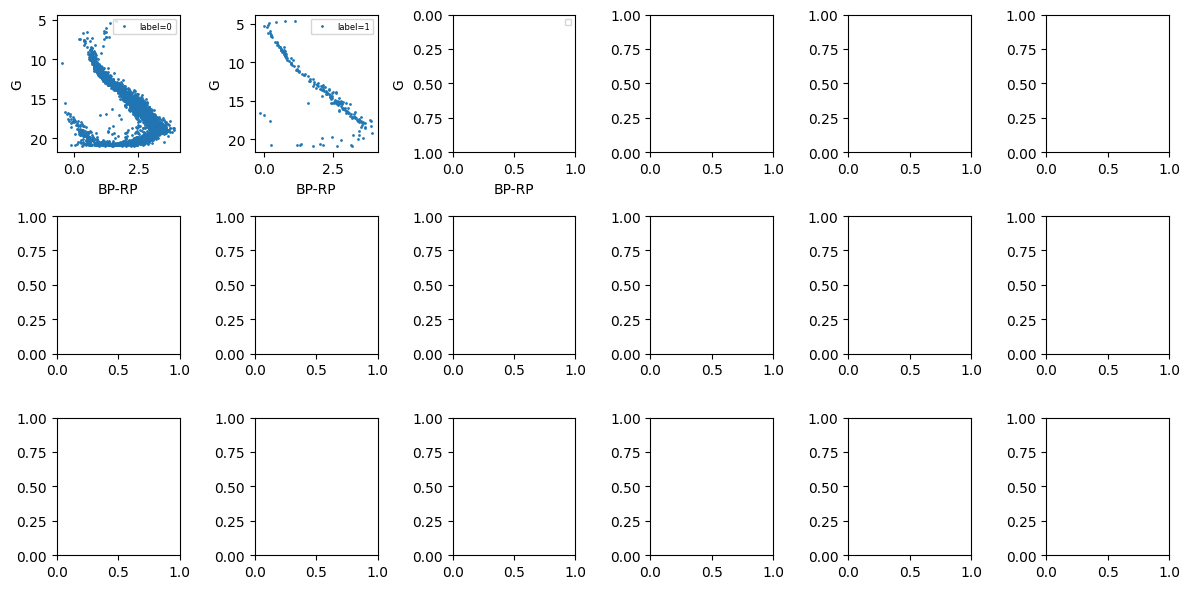

Número de elementos: 3321
Número de elementos: 230


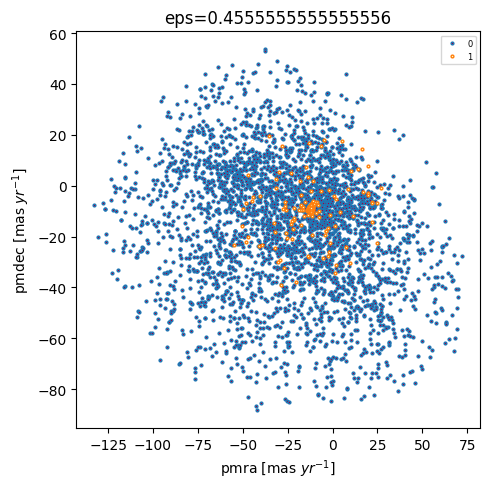

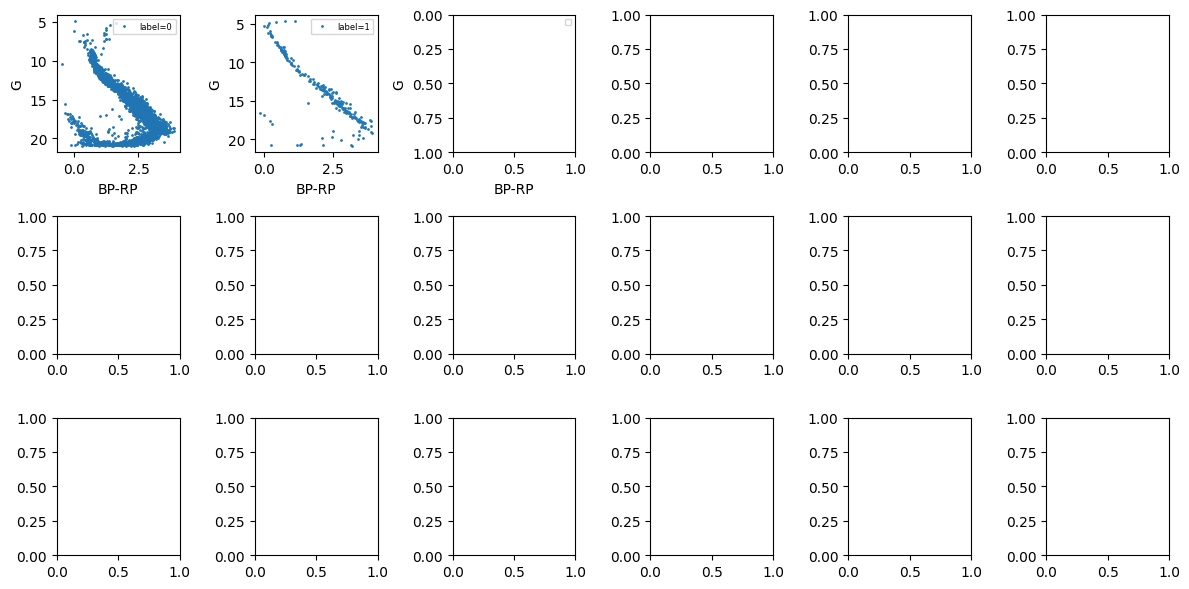

Número de elementos: 3536
Número de elementos: 232


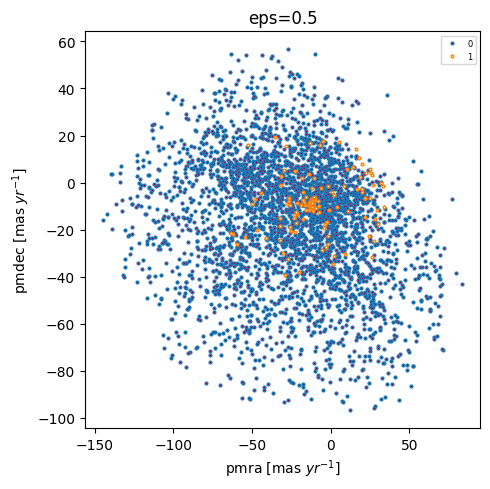

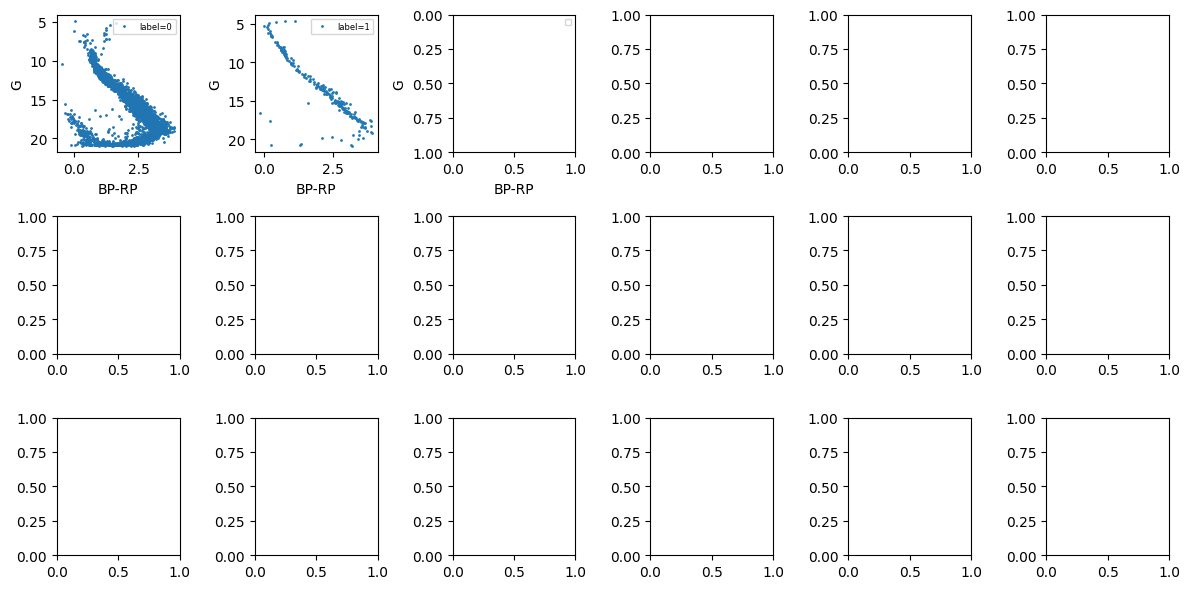

In [8]:
for eps_ in eps_grid:

    db = DBSCAN(eps=eps_, min_samples=100).fit(data) # n_jobs=-1

    labels = db.labels_
    df['label_db'] = labels

    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

    plt.figure(figsize=(5,5))
    plt.title(f"eps={eps_}")
    for i, j in zip(list(unique_labels), colors):
        if i != -1:
            plt.plot(df['pmra'][(df['label_db'] == i)], df['pmdec'][(df['label_db'] == i)], label=f"{i}",
            markerfacecolor=tuple(j), marker = 'o', linestyle='None',markersize=2, alpha=1)
            print(f"Número de elementos: {df[(df['label_db'] == i)].shape[0]}")
    plt.xlabel("pmra [mas $yr^{-1}$]")
    plt.ylabel("pmdec [mas $yr^{-1}$]")
    plt.legend(fontsize=6)
    plt.tight_layout()
    plt.show() 


    fig, axes = plt.subplots(3, 6, figsize=(12,6))
    for i, j, ax in zip(list(unique_labels), colors, axes.flat):
        if i != -1:
            condition = (df['label_db'] == i)
            ax.plot(df['phot_bp_mean_mag'][condition] - df['phot_rp_mean_mag'][condition], df['phot_g_mean_mag'][condition], 
            markerfacecolor = tuple(j),marker = 'o', linestyle='None', markersize=1, label=f'label={i}')
        ax.set_xlabel("BP-RP")
        ax.set_ylabel("G")
        ax.invert_yaxis()
        ax.legend(fontsize=6)

    fig.tight_layout()
    plt.show() 

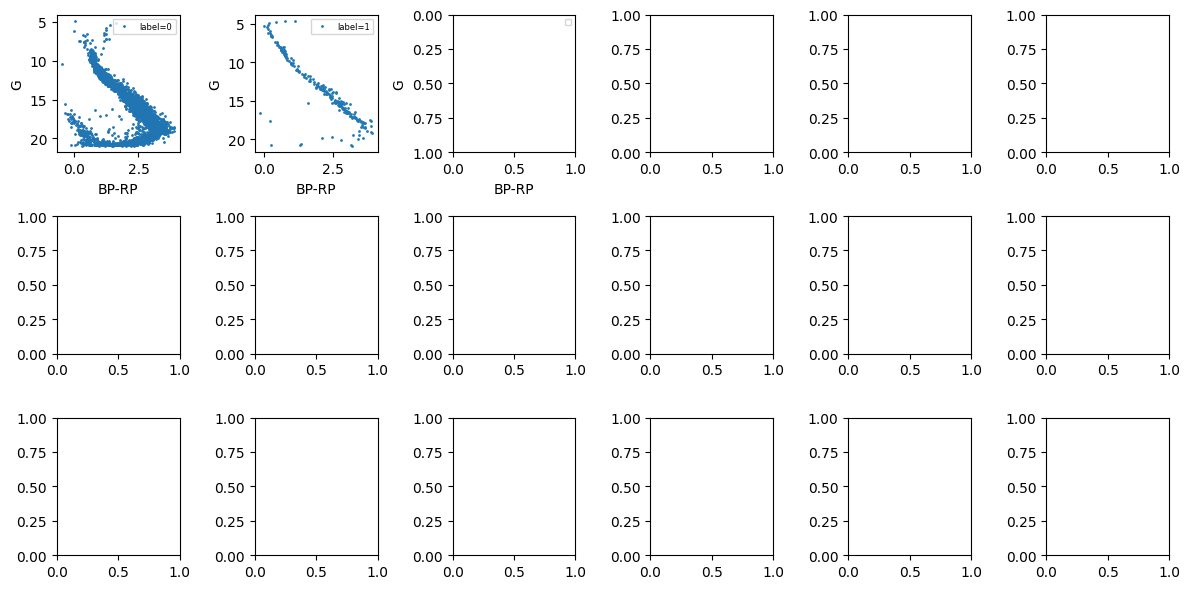

In [9]:
fig, axes = plt.subplots(3, 6, figsize=(12,6))

for i, j, ax in zip(list(unique_labels), colors, axes.flat):
    if i != -1:
        condition = (df['label_db'] == i)
        ax.plot(df['phot_bp_mean_mag'][condition] - df['phot_rp_mean_mag'][condition], df['phot_g_mean_mag'][condition], 
         markerfacecolor = tuple(j),marker = 'o', linestyle='None', markersize=1, label=f'label={i}')
    ax.set_xlabel("BP-RP")
    ax.set_ylabel("G")
    ax.invert_yaxis()
    ax.legend(fontsize=6)

fig.tight_layout()
plt.show() 

<div align="center">

# HDBSCAN

</div>

* Compute the core distance1 for the k nearest neighbors for all points in the set
* Compute the extended minimum spanning tree from a weighted graph, where the mutual reachability distances2 are the edges
* Build the HDBSCAN hierarchy from the extended minimum spanning tree
* Find the prominent clusters from the hierarchy

<div align="center">

<div align="center">
<img src="../images/hdbscan.png" alt="membership" width="1200"/>
</div>

Schematic representation of HDBSCAN (Campello+2013)
</div>

* k(i) = distance from i to its kth nearest neighbor
* dmr(i,j) = max{k(i), k(j), d(I,j) if i≠j}; 0 if i=j


### HDBSCAN Hyperparameters  

- **`min_cluster_size`:**  
  Minimum number of points needed to form a cluster. Smaller values detect smaller clusters.  

- **`min_samples`:**  
  Controls how conservative the clustering is. Higher values make clusters more robust to noise.  

- **`cluster_selection_epsilon`:**  
  A distance threshold for merging clusters. Works similarly to `eps` in DBSCAN.  

- **`metric`:**  
  Distance metric used to compute point similarity (default: `'euclidean'`).  

- **`cluster_selection_method`:**  
  Determines how clusters are extracted (`'eom'` for excess of mass, `'leaf'` for leaf clusters).  

- **`alpha`:**  
  Controls the relative importance of density-based and distance-based clustering.  

- **`leaf_size`:**  
  Affects the speed of KD-tree and Ball-tree nearest neighbor searches.  

- **`core_dist_n_jobs`:**  
  Number of parallel jobs for computing core distances (`-1` uses all processors).  


In [10]:
#hd = HDBSCAN(min_cluster_size=20, min_samples=5, metric='mahalanobis', metric_params={'V': np.cov(data, rowvar=False)}).fit(data)
hd = HDBSCAN(min_cluster_size=30, min_samples=10, metric='euclidean').fit(data)

In [11]:
labels = hd.labels_ 
df['label_hb'] = labels
for i in list(set(labels)):
    print('{} {}'.format(i,len(df[(df['label_hb'] == i)])))

0 2981
1 155
-1 1874


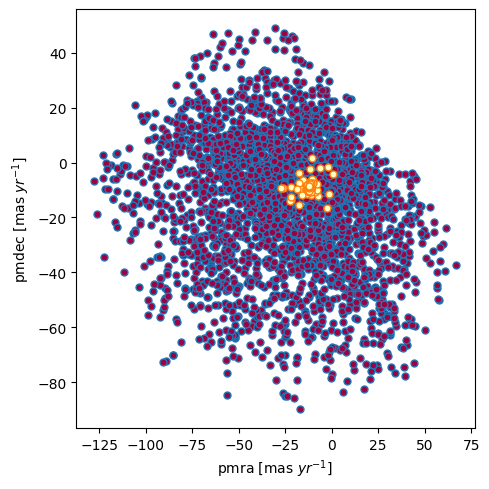

In [12]:
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(5,5))
for i, j in zip(list(unique_labels), colors):
    if i != -1:
        condition = (df['label_hb'] == i)
        plt.plot(df['pmra'][condition], df['pmdec'][condition], 
         markerfacecolor = tuple(j),marker = 'o', linestyle='None',markersize = 5, alpha = 1)
plt.xlabel("pmra [mas $yr^{-1}$]")
plt.ylabel("pmdec [mas $yr^{-1}$]")
plt.tight_layout()
plt.show() 

In [13]:
from sklearn.metrics import silhouette_samples, silhouette_score
#mask = labels != -1
#data_clustered = data[mask]
#labels_clustered = labels[mask]

data_clustered = data
labels_clustered = labels

sil_score = silhouette_score(data_clustered, labels_clustered)

print("Silhouette score:", sil_score)

Silhouette score: 0.1625212934953969


In [14]:
sil_values = silhouette_samples(data_clustered, labels_clustered)

In [15]:
df_sil = pd.DataFrame({
    "cluster": labels_clustered,
    "silhouette": sil_values
})
sil_cluster = df_sil.groupby('cluster')['silhouette'].mean()

print(df_sil.groupby("cluster").mean())

         silhouette
cluster            
-1        -0.372458
 0         0.460233
 1         0.904925


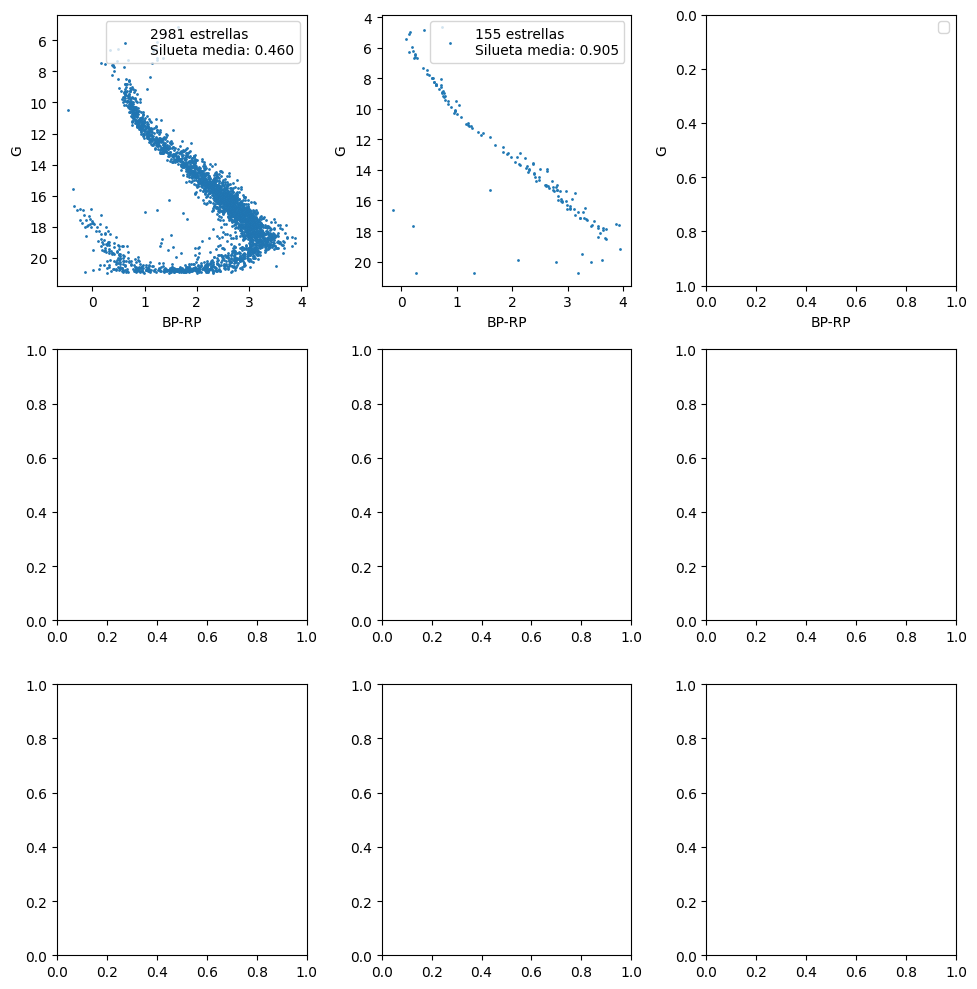

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(10,10))

for i, j, ax in zip(list(unique_labels), colors, axes.flat):
    if i != -1:
        condition = (df['label_hb'] == i)
        sil = sil_cluster.loc[i]
        ax.plot(df['phot_bp_mean_mag'][condition] - df['phot_rp_mean_mag'][condition], df['phot_g_mean_mag'][condition], 
         markerfacecolor = tuple(j), marker='o', linestyle='None', markersize=1, label=f'{len(df[condition])} estrellas\nSilueta media: {sil:.3f}')
    ax.set_xlabel("BP-RP")
    ax.set_ylabel("G")
    ax.invert_yaxis()
    ax.legend()

fig.tight_layout()
plt.show() 

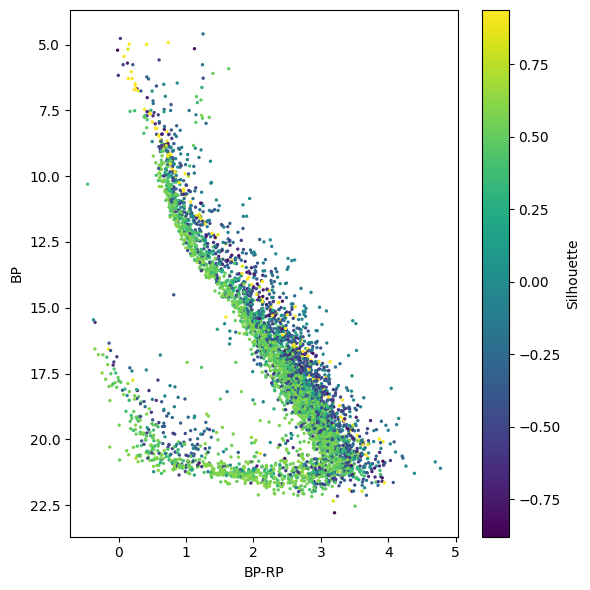

In [17]:
fig, ax = plt.subplots(figsize=(6,6))

sc = ax.scatter(
    df["phot_bp_mean_mag"] - df["phot_rp_mean_mag"], 
    df["phot_bp_mean_mag"],
    c=df_sil["silhouette"],
    cmap="viridis",
    s=2
)

ax.set_xlabel("BP-RP")
ax.set_ylabel("BP")
ax.invert_yaxis()

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Silhouette")

plt.tight_layout()
plt.show()

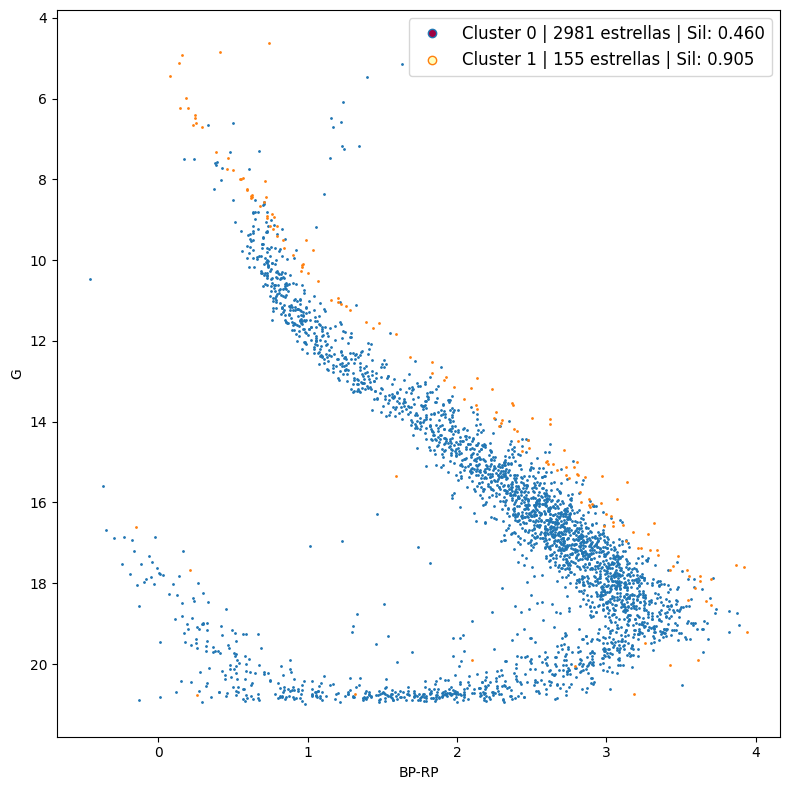

In [18]:
fig, ax = plt.subplots(figsize=(8,8))

for i, j in zip(list(unique_labels), colors):

    if i != -1:
        condition = (df['label_hb'] == i)
        sil = sil_cluster.loc[i]

        ax.plot(
            df['phot_bp_mean_mag'][condition] - df['phot_rp_mean_mag'][condition],
            df['phot_g_mean_mag'][condition],
            marker='o',
            linestyle='None',
            markersize=1,
            markerfacecolor=tuple(j),
            label=f'Cluster {i} | {len(df[condition])} estrellas | Sil: {sil:.3f}'
        )

ax.set_xlabel("BP-RP")
ax.set_ylabel("G")
ax.invert_yaxis()

ax.legend(markerscale=6, fontsize=12)

plt.tight_layout()
plt.show()

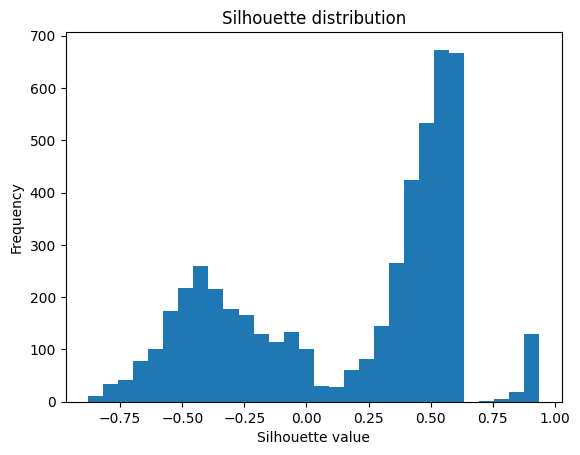

In [19]:
plt.hist(sil_values, bins=30)
plt.xlabel("Silhouette value")
plt.ylabel("Frequency")
plt.title("Silhouette distribution")
plt.show()

In [20]:
sil_cluster

cluster
-1   -0.372458
 0    0.460233
 1    0.904925
Name: silhouette, dtype: float64

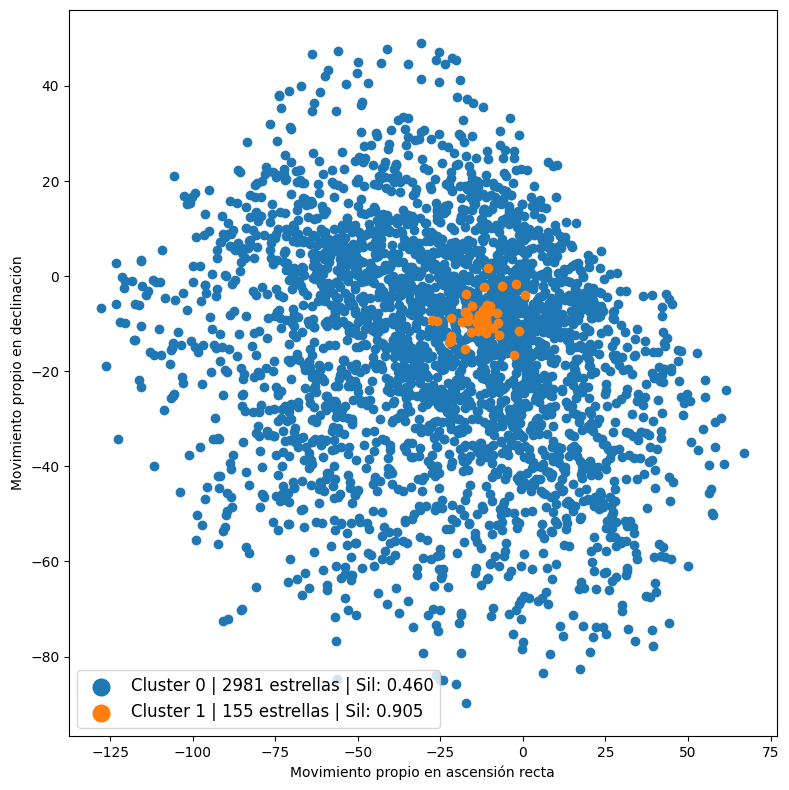

In [21]:
fig, ax = plt.subplots(figsize=(8,8))

for i, j in zip(list(unique_labels), colors):

    if i != -1:
        condition = (df['label_hb'] == i)
        sil = sil_cluster.loc[i]

        ax.scatter(
            df['pmra'][condition],
            df['pmdec'][condition],
            label=f'Cluster {i} | {len(df[condition])} estrellas | Sil: {sil:.3f}'
        )

ax.set_xlabel("Movimiento propio en ascensión recta")
ax.set_ylabel("Movimiento propio en declinación")

ax.legend(markerscale=2, fontsize=12)

plt.tight_layout()
plt.show()